# Exploratory Data Analysis — TheLook Customer Analysis

**Scope:** Customer Analysis — who are our customers, how much value do they generate, how do they buy?

**Tables:** `users`, `orders`, `order_items`, `products`

**Data path:** `../data/raw/`

## 0. Imports & Load Data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW = os.path.join("..", "data", "raw")

order_items = pd.read_csv(os.path.join(RAW, "order_items.csv"))
orders      = pd.read_csv(os.path.join(RAW, "orders.csv"))
products    = pd.read_csv(os.path.join(RAW, "products.csv"))
users       = pd.read_csv(os.path.join(RAW, "users.csv"))

In [2]:
# Parse datetime columns
users['created_at'] = pd.to_datetime(users['created_at'], format='mixed', utc=True)

for col in ['created_at', 'shipped_at', 'delivered_at', 'returned_at']:
    order_items[col] = pd.to_datetime(order_items[col], format='mixed', utc=True)
    orders[col]      = pd.to_datetime(orders[col],      format='mixed', utc=True)

## 1. Dataset Overview

In [3]:
tables = {
    "order_items": order_items,
    "orders":      orders,
    "products":    products,
    "users":       users,
}

print("Shape:")
for name, df in tables.items():
    print(f"  {name:<15} {df.shape[0]:>9,} rows  x  {df.shape[1]} cols")

print("\nDate range:")
for name, df in tables.items():
    if 'created_at' in df.columns:
        print(f"  {name:<15} {str(df['created_at'].min())[:10]}  →  {str(df['created_at'].max())[:10]}")

Shape:
  order_items       180,862 rows  x  11 cols
  orders            124,814 rows  x  9 cols
  products           29,120 rows  x  9 cols
  users             100,000 rows  x  15 cols

Date range:
  order_items     2019-01-09  →  2024-05-13
  orders          2019-01-09  →  2024-05-09
  users           2019-01-02  →  2024-05-08


## 2. Data Quality

### 2.1 Missing Values (%)

In [4]:
for name, df in tables.items():
    missing = (df.isnull().sum() / len(df) * 100).round(2)
    missing = missing[missing > 0]
    if not missing.empty:
        print(f"\n── {name} ──")
        print(missing.to_string())
    else:
        print(f"\n── {name} ── no missing values")


── order_items ──
shipped_at      34.80
delivered_at    64.91
returned_at     90.02

── orders ──
returned_at     90.03
shipped_at      34.74
delivered_at    64.85

── products ──
name     0.01
brand    0.08

── users ──
city    0.96


### 2.2 Duplicate Rows

In [5]:
for name, df in tables.items():
    print(f"  {name:<15} {df.duplicated().sum():>5} duplicates")

  order_items         0 duplicates
  orders              0 duplicates
  products            0 duplicates
  users               0 duplicates


## 3. Table: users

### 3.1 Age Distribution

count    100000.00
mean         41.06
std          17.07
min          12.00
25%          26.00
50%          41.00
75%          56.00
max          70.00
Name: age, dtype: float64


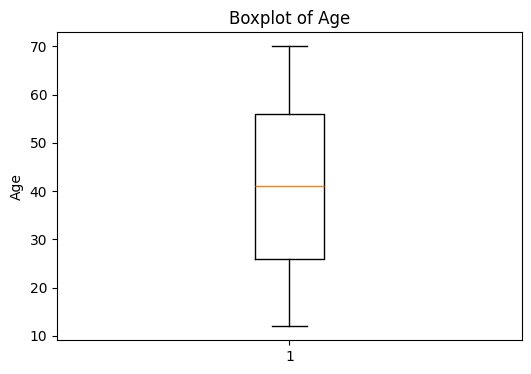


Age group distribution:
age_group
<18      10125
18-23    10298
24-33    16797
34-43    16898
44-53    16789
54+      29093
Name: count, dtype: int64


In [6]:
print(users['age'].describe().round(2))

plt.figure(figsize=(6, 4))
plt.boxplot(users['age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')
plt.show()

# Age groups — matches SQL definition in customer_analysis.sql
# SQL: age<18 Teen | age<24 Gen Z | age<34 Young Prof | age<44 Mid-age | age<54 Mature | else Senior
users['age_group'] = pd.cut(
    users['age'],
    bins=[-1, 17, 23, 33, 43, 53, float('inf')],
    labels=['<18', '18-23', '24-33', '34-43', '44-53', '54+']
)
print("\nAge group distribution:")
print(users['age_group'].value_counts().sort_index())

### 3.2 Gender & Country

In [7]:
print("Gender (%):\n", users['gender'].value_counts(normalize=True).mul(100).round(2).to_string())
print("\nTop 10 Countries:\n", users['country'].value_counts().head(10).to_string())

Gender (%):
 gender
M    50.15
F    49.85

Top 10 Countries:
 country
China             33893
United States     22309
Brasil            14669
South Korea        5328
United Kingdom     4678
France             4612
Germany            4248
Spain              4065
Japan              2471
Australia          2234


### 3.3 Traffic Source (Acquisition)

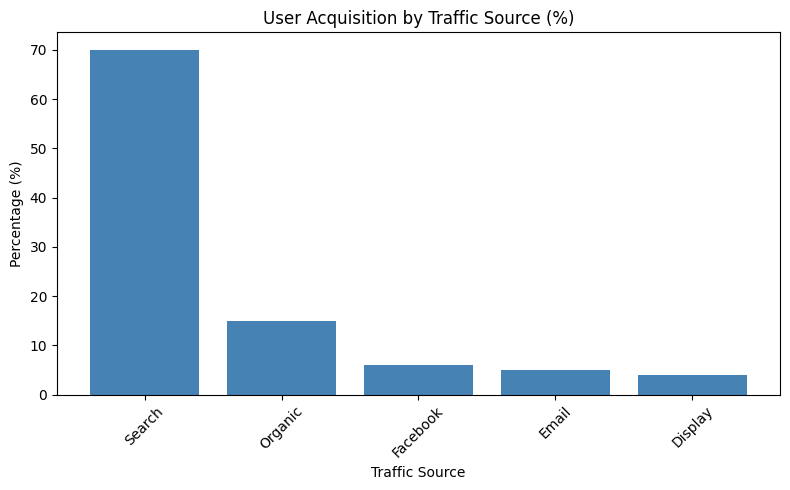

traffic_source
Search      70.07
Organic     14.95
Facebook     5.99
Email        4.99
Display      4.00
Name: proportion, dtype: float64


In [8]:
pct_ut = (users['traffic_source'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(8, 5))
plt.bar(pct_ut.index, pct_ut.values, color='steelblue')
plt.ylabel('Percentage (%)')
plt.xlabel('Traffic Source')
plt.title('User Acquisition by Traffic Source (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(pct_ut)

### 3.4 User Registration Over Time

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_13092\2799992347.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  users['month'] = users['created_at'].dt.to_period('M')


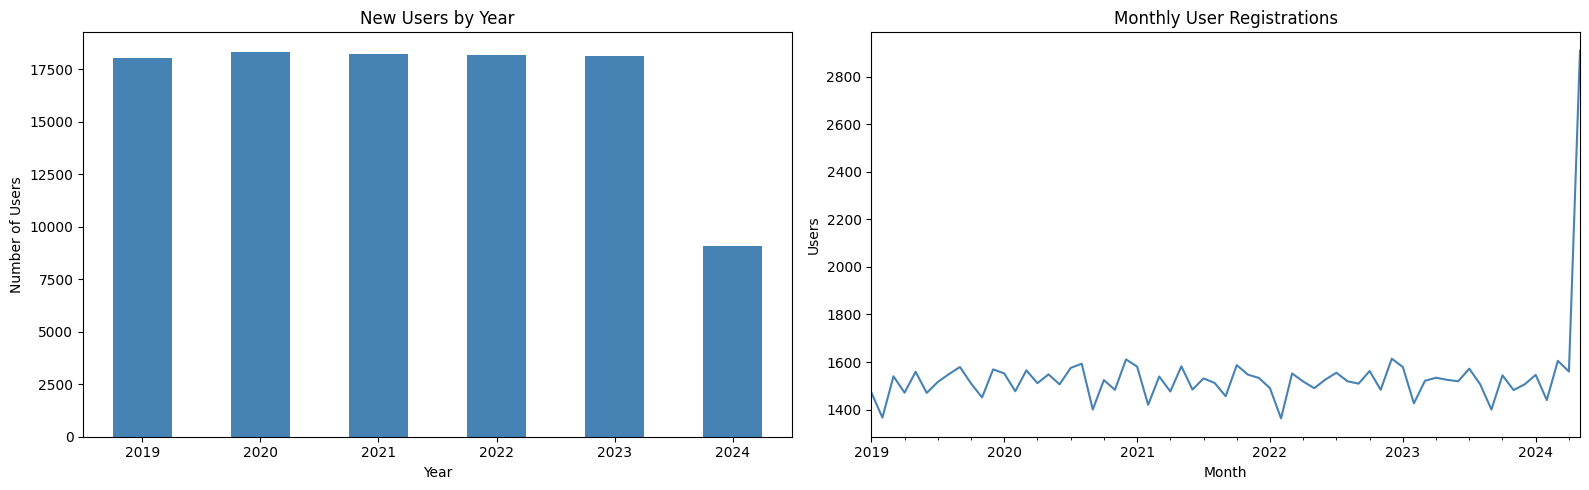

In [9]:
users['year']  = users['created_at'].dt.year
users['month'] = users['created_at'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

users.groupby('year').size().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('New Users by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=0)

users.groupby('month').size().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Monthly User Registrations')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Users')
axes[1].grid(False)

plt.tight_layout()
plt.show()

> User acquisition grows steadily year-on-year. 2024 appears lower because data only covers partial year.

## 4. Tables: orders & order_items

### 4.1 Order Status

In [10]:
print("orders status (%):\n",
      orders['status'].value_counts(normalize=True).mul(100).round(2).to_string())

print("\norder_items status (%):\n",
      order_items['status'].value_counts(normalize=True).mul(100).round(2).to_string())

item_per_order = orders.groupby('order_id')['num_of_item'].sum().mean()
print(f"\nAvg items per order: {item_per_order:.2f}")

orders status (%):
 status
Shipped       30.11
Complete      25.18
Processing    19.77
Cancelled     14.97
Returned       9.97

order_items status (%):
 status
Shipped       30.11
Complete      25.11
Processing    19.83
Cancelled     14.97
Returned       9.98

Avg items per order: 1.45


### 4.2 Conversion: Registered → Purchased

In [11]:
total_users      = users['id'].nunique()
completed_orders = orders[orders['status'] == 'Complete']
buyers           = completed_orders['user_id'].nunique()
conversion_rate  = buyers / total_users * 100

print(f"Total registered users: {total_users:,}")
print(f"Users who purchased:    {buyers:,}")
print(f"Conversion rate:        {conversion_rate:.1f}%")

Total registered users: 100,000
Users who purchased:    27,775
Conversion rate:        27.8%


### 4.3 Sale Price Distribution

count    180862.00
mean         59.69
std          66.88
min           0.02
25%          24.95
50%          39.99
75%          69.95
max         999.00
Name: sale_price, dtype: float64


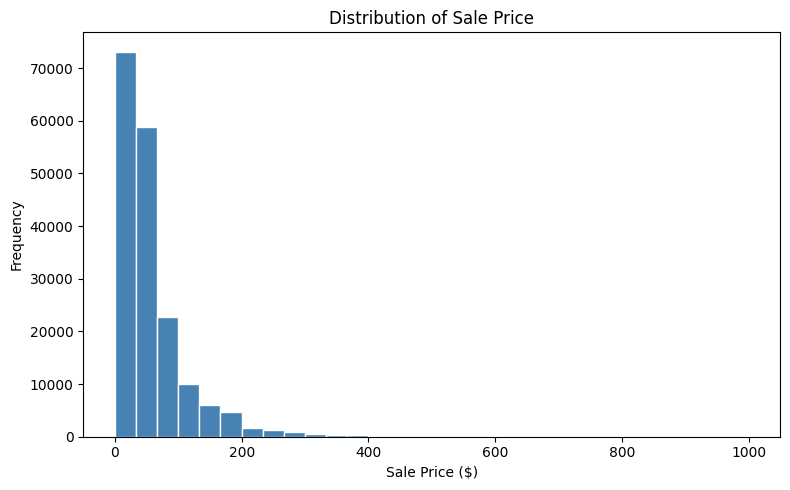

In [12]:
print(order_items['sale_price'].describe().round(2))

plt.figure(figsize=(8, 5))
plt.hist(order_items['sale_price'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Sale Price')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

> Right-skewed: most products are priced $0–$100, with a long tail of high-value items.

### 4.4 Revenue from Completed Orders

In [13]:
completed     = order_items[order_items['status'] == 'Complete']
total_revenue = completed['sale_price'].sum()
aov           = completed.groupby('order_id')['sale_price'].sum().mean()

print(f"Total revenue (completed):  ${total_revenue:,.2f}")
print(f"Average Order Value (AOV):  ${aov:,.2f}")

Total revenue (completed):  $2,729,363.48
Average Order Value (AOV):  $86.84


## 5. Table: products

### 5.1 Category & Department

In [14]:
print("Top Categories:\n", products['category'].value_counts().head(10).to_string())
print("\nDepartment split:\n", products['department'].value_counts().to_string())

Top Categories:
 category
Intimates                        2363
Jeans                            1999
Tops & Tees                      1868
Fashion Hoodies & Sweatshirts    1866
Swim                             1798
Sleep & Lounge                   1771
Shorts                           1765
Sweaters                         1737
Accessories                      1559
Active                           1432

Department split:
 department
Women    15989
Men      13131


### 5.2 Price Range by Category

In [15]:
price_by_cat = products.groupby('category')['retail_price'].agg(['mean', 'median']).round(2)
print(price_by_cat.sort_values('mean', ascending=False).to_string())

                                 mean  median
category                                     
Outerwear & Coats              146.02  109.95
Suits & Sport Coats            126.56   99.50
Suits                          116.16  122.71
Jeans                           97.85   78.00
Blazers & Jackets               92.60   59.99
Clothing Sets                   84.84   70.00
Dresses                         84.20   59.00
Sweaters                        75.32   58.99
Pants                           59.81   49.99
Swim                            57.82   49.99
Pants & Capris                  54.71   40.00
Fashion Hoodies & Sweatshirts   53.92   49.50
Skirts                          52.33   36.99
Maternity                       50.80   39.98
Active                          50.62   33.98
Sleep & Lounge                  49.22   36.99
Shorts                          45.77   39.60
Jumpsuits & Rompers             45.42   24.94
Accessories                     42.57   24.30
Tops & Tees                     41

---

## Summary of Key Findings

| Area | Observation |
|---|---|
| Users | Registration grows YoY; gender split ~50/50; age groups balanced |
| Conversion | Only ~27–28% of registered users ever complete a purchase |
| Orders | High cancel/return rate warrants investigation |
| Price | Right-skewed — majority of items under $100 |
| Products | Diverse category mix; Outerwear & Coats tend to be highest priced |